# Assignment 3 — Image Classification Using Pretrained CNN Architectures
## Implementation and Performance Comparison of ResNet50 and InceptionV3 (Transfer Learning)

**Dataset:** CIFAR-10 (10 classes)

**Models:**
- ResNet50 (ImageNet pretrained)
- InceptionV3 (ImageNet pretrained)

**What this notebook produces (deliverables):**
- Training curves (accuracy/loss vs epoch)
- Confusion matrices (test set)
- Metrics + training time + model size comparison table
- Saved models + CSV histories + a short auto-generated report markdown

> Recommended: Run on **Google Colab with GPU** (Runtime → Change runtime type → GPU).

In [1]:
# ===== Setup =====
import os
import json
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

# Make Matplotlib cache writable (important on Colab and some locked-down envs)
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplconfig')

SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# ===== Google Drive output directory (Colab-friendly) =====
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Abdul_Basit_Assignment_03')
else:
    PROJECT_ROOT = Path('.')

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT:', PROJECT_ROOT.resolve())

DIRS = {
    'results': PROJECT_ROOT / 'results',
    'figures': PROJECT_ROOT / 'figures',
    'models': PROJECT_ROOT / 'models',
    'report': PROJECT_ROOT / 'report',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Abdul_Basit_Assignment_03


In [2]:
# ===== Load CIFAR-10 =====
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.squeeze().astype(np.int64)
y_test = y_test.squeeze().astype(np.int64)

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

num_classes = len(CLASS_NAMES)
print('Train:', x_train.shape, y_train.shape)
print('Test :', x_test.shape, y_test.shape)
print('Classes:', num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)
Classes: 10


In [3]:
# ===== Train/Val split =====
val_fraction = 0.1
num_train = x_train.shape[0]
idx = np.arange(num_train)
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

val_size = int(num_train * val_fraction)
val_idx = idx[:val_size]
train_idx = idx[val_size:]

x_tr, y_tr = x_train[train_idx], y_train[train_idx]
x_va, y_va = x_train[val_idx], y_train[val_idx]

print('Train split:', x_tr.shape, y_tr.shape)
print('Val split  :', x_va.shape, y_va.shape)

Train split: (45000, 32, 32, 3) (45000,)
Val split  : (5000, 32, 32, 3) (5000,)


In [4]:
# ===== tf.data pipeline (model-specific preprocessing) =====
def make_datasets(*, image_size, preprocess_fn, batch_size=64):
    image_size = tuple(image_size)

    def to_example(x, y, training):
        x = tf.cast(x, tf.float32)
        x = tf.image.resize(x, image_size, method='bilinear')
        if training:
            x = tf.image.random_flip_left_right(x, seed=SEED)
            x = tf.image.random_brightness(x, max_delta=0.08, seed=SEED)
            x = tf.image.random_contrast(x, lower=0.9, upper=1.1, seed=SEED)
        x = preprocess_fn(x)
        y = tf.one_hot(y, depth=num_classes)
        return x, y

    ds_train = tf.data.Dataset.from_tensor_slices((x_tr, y_tr))
    ds_val = tf.data.Dataset.from_tensor_slices((x_va, y_va))
    ds_test = tf.data.Dataset.from_tensor_slices((x_test, y_test))

    ds_train = (
        ds_train
        .shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)
        .map(lambda x, y: to_example(x, y, True), num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )
    ds_val = (
        ds_val
        .map(lambda x, y: to_example(x, y, False), num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )
    ds_test = (
        ds_test
        .map(lambda x, y: to_example(x, y, False), num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )
    return ds_train, ds_val, ds_test

def preview_batch(ds, title):
    x_b, y_b = next(iter(ds.take(1)))
    plt.figure(figsize=(9, 3))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        # show preprocessed tensor by rescaling to [0,1] for display only
        img = x_b[i].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.imshow(img)
        label = int(tf.argmax(y_b[i]).numpy())
        plt.title(CLASS_NAMES[label])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [5]:
# ===== Model builders =====
def build_resnet50(input_size=(224, 224)):
    preprocess = tf.keras.applications.resnet50.preprocess_input
    base = tf.keras.applications.ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(input_size[0], input_size[1], 3),
        pooling='avg',
    )
    return base, preprocess

def build_inceptionv3(input_size=(299, 299)):
    preprocess = tf.keras.applications.inception_v3.preprocess_input
    base = tf.keras.applications.InceptionV3(
        include_top=False,
        weights='imagenet',
        input_shape=(input_size[0], input_size[1], 3),
        pooling='avg',
    )
    return base, preprocess

def build_transfer_model(base_model, *, dropout=0.25):
    base_model.trainable = False

    inputs = tf.keras.Input(shape=base_model.input_shape[1:])
    x = base_model(inputs, training=False)
    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    return model

def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

def unfreeze_for_finetune(base_model, *, unfreeze_last_n=40):
    # Unfreeze last N layers, but keep BatchNorm frozen (stability for transfer learning)
    base_model.trainable = True
    if unfreeze_last_n is None:
        layers_to_train = base_model.layers
    else:
        layers_to_train = base_model.layers[-unfreeze_last_n:]

    for layer in base_model.layers:
        layer.trainable = False
    for layer in layers_to_train:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

In [6]:
# ===== Training + evaluation helpers =====
@dataclass
class RunSummary:
    model_name: str
    image_size: int
    epochs_head: int
    epochs_finetune: int
    train_time_sec: float
    test_loss: float
    test_accuracy: float
    params_million: float
    saved_model_mb: float

def save_history_csv(history, path: Path):
    keys = list(history.history.keys())
    rows = []
    for i in range(len(history.history[keys[0]])):
        row = {k: float(history.history[k][i]) for k in keys}
        row['epoch'] = i + 1
        rows.append(row)
    import csv
    with path.open('w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['epoch'] + keys)
        w.writeheader()
        w.writerows(rows)

def plot_curves(hist_head, hist_ft, title, out_path: Path):
    acc = hist_head.history.get('accuracy', []) + hist_ft.history.get('accuracy', [])
    val_acc = hist_head.history.get('val_accuracy', []) + hist_ft.history.get('val_accuracy', [])
    loss = hist_head.history.get('loss', []) + hist_ft.history.get('loss', [])
    val_loss = hist_head.history.get('val_loss', []) + hist_ft.history.get('val_loss', [])
    epochs = np.arange(1, len(acc) + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='train')
    plt.plot(epochs, val_acc, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} — Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='train')
    plt.plot(epochs, val_loss, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} — Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

def confusion_matrix_and_plot(model, ds_test, title, out_path: Path):
    y_true = []
    y_pred = []
    for x_b, y_b in ds_test:
        p = model.predict(x_b, verbose=0)
        y_true.append(tf.argmax(y_b, axis=1).numpy())
        y_pred.append(np.argmax(p, axis=1))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

    plt.figure(figsize=(8, 6))
    if sns is not None:
        sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
    else:
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

    return cm

def get_saved_model_size_mb(model, out_path: Path):
    model.save(out_path, include_optimizer=False)
    size_bytes = out_path.stat().st_size
    return size_bytes / (1024 * 1024)

def train_and_evaluate(
    *,
    model_name,
    build_base_fn,
    image_size,
    epochs_head=5,
    epochs_finetune=5,
    batch_size=64,
    lr_head=1e-3,
    lr_finetune=1e-5,
    unfreeze_last_n=40,
):
    base, preprocess = build_base_fn((image_size, image_size))
    ds_train, ds_val, ds_test = make_datasets(
        image_size=(image_size, image_size),
        preprocess_fn=preprocess,
        batch_size=batch_size,
    )
    preview_batch(ds_train, f'{model_name} — preprocessed samples')

    model = build_transfer_model(base)
    compile_model(model, lr=lr_head)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ]

    t0 = time.perf_counter()
    hist_head = model.fit(ds_train, validation_data=ds_val, epochs=epochs_head, callbacks=callbacks)

    unfreeze_for_finetune(base, unfreeze_last_n=unfreeze_last_n)
    compile_model(model, lr=lr_finetune)
    hist_ft = model.fit(ds_train, validation_data=ds_val, epochs=epochs_finetune, callbacks=callbacks)
    t1 = time.perf_counter()

    train_time = t1 - t0
    test_loss, test_acc = model.evaluate(ds_test, verbose=0)

    # Save outputs
    model_path = DIRS['models'] / f'{model_name.lower()}_cifar10_transfer.keras'
    model_mb = get_saved_model_size_mb(model, model_path)

    save_history_csv(hist_head, DIRS['results'] / f'history_{model_name.lower()}_head.csv')
    save_history_csv(hist_ft, DIRS['results'] / f'history_{model_name.lower()}_finetune.csv')

    fig_curves = DIRS['figures'] / f'{model_name.lower()}_accuracy_loss.png'
    plot_curves(hist_head, hist_ft, model_name, fig_curves)

    fig_cm = DIRS['figures'] / f'confusion_matrix_{model_name.lower()}.png'
    cm = confusion_matrix_and_plot(model, ds_test, model_name, fig_cm)
    np.save(DIRS['results'] / f'confusion_matrix_{model_name.lower()}.npy', cm)

    params = model.count_params() / 1e6

    summary = RunSummary(
        model_name=model_name,
        image_size=image_size,
        epochs_head=epochs_head,
        epochs_finetune=epochs_finetune,
        train_time_sec=float(train_time),
        test_loss=float(test_loss),
        test_accuracy=float(test_acc),
        params_million=float(params),
        saved_model_mb=float(model_mb),
    )
    with (DIRS['results'] / f'summary_{model_name.lower()}.json').open('w') as f:
        json.dump(asdict(summary), f, indent=2)

    return summary

## Train ResNet50 (Transfer Learning)
We train in two stages:
1) **Frozen backbone** (train only the new classifier head)
2) **Fine-tuning** (unfreeze the last layers of the backbone with a smaller learning rate)

Total epochs = `epochs_head + epochs_finetune` (10–20 as required).

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


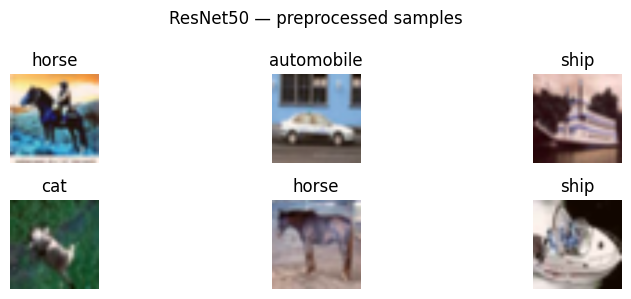

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.8363 - loss: 0.4759 - val_accuracy: 0.8912 - val_loss: 0.3191 - learning_rate: 0.0010
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.8874 - loss: 0.3262 - val_accuracy: 0.9070 - val_loss: 0.2800 - learning_rate: 0.0010
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.8953 - loss: 0.3063 - val_accuracy: 0.9094 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.8970 - loss: 0.2972 - val_accuracy: 0.9106 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9004 - loss: 0.2850 - val_accuracy: 0.9132 - val_loss: 0.2541 - learning_rate: 0.0010
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.9276 - loss: 0.2052 - val_accuracy: 0.9376 - val_loss: 0.1816 - learning_rate: 1.0000e-05
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9556 - loss

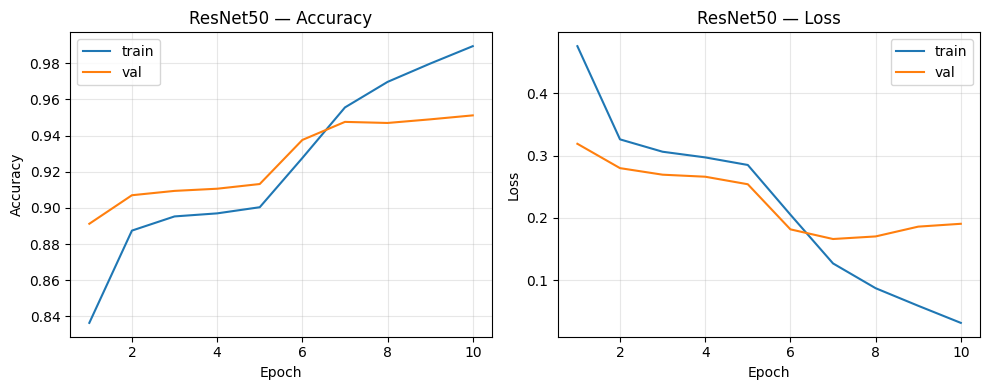

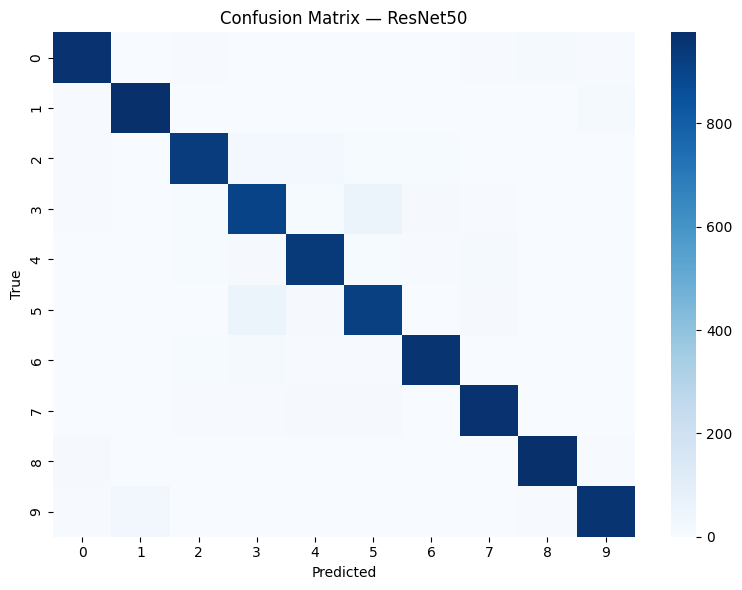

RunSummary(model_name='ResNet50', image_size=224, epochs_head=5, epochs_finetune=5, train_time_sec=368.94099438700005, test_loss=0.18624146282672882, test_accuracy=0.9474999904632568, params_million=23.608202, saved_model_mb=228.48646926879883)

In [7]:
resnet_summary = train_and_evaluate(
    model_name='ResNet50',
    build_base_fn=lambda input_size: build_resnet50(input_size),
    image_size=224,
    epochs_head=5,
    epochs_finetune=5,
    batch_size=64,
    lr_head=1e-3,
    lr_finetune=1e-5,
    unfreeze_last_n=60,
)
resnet_summary

## Train InceptionV3 (Transfer Learning)
InceptionV3 expects a larger input size (commonly 299×299).

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


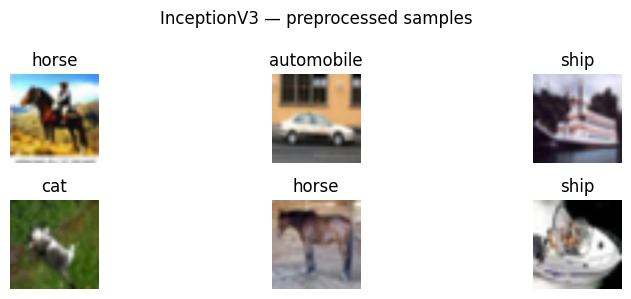

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.8117 - loss: 0.5701 - val_accuracy: 0.8494 - val_loss: 0.4285 - learning_rate: 0.0010
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8596 - loss: 0.4171 - val_accuracy: 0.8706 - val_loss: 0.3729 - learning_rate: 0.0010
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8667 - loss: 0.3935 - val_accuracy: 0.8676 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8705 - loss: 0.3751 - val_accuracy: 0.8790 - val_loss: 0.3558 - learning_rate: 0.0010
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8744 - loss: 0.3680 - val_accuracy: 0.8850 - val_loss: 0.3393 - learning_rate: 0.0010
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 65ms/step - accuracy: 0.8976 - loss: 0.2955 - val_accuracy: 0.9138 - val_loss: 0.2574 - learning_rate: 1.0000e-05
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.9293 - loss

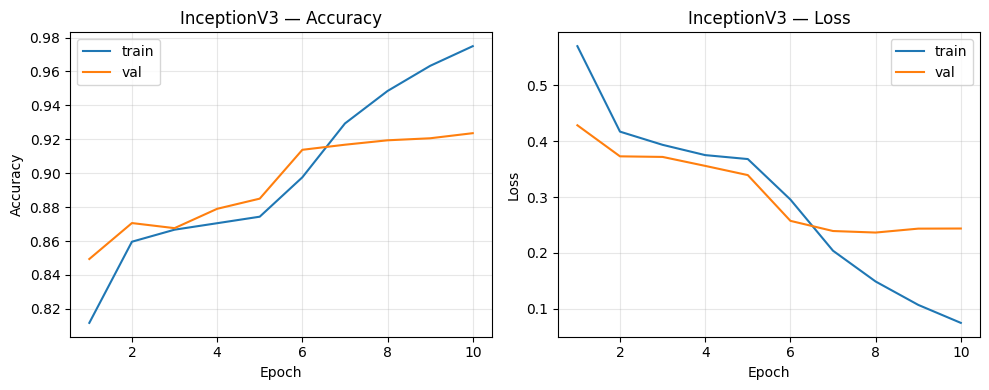

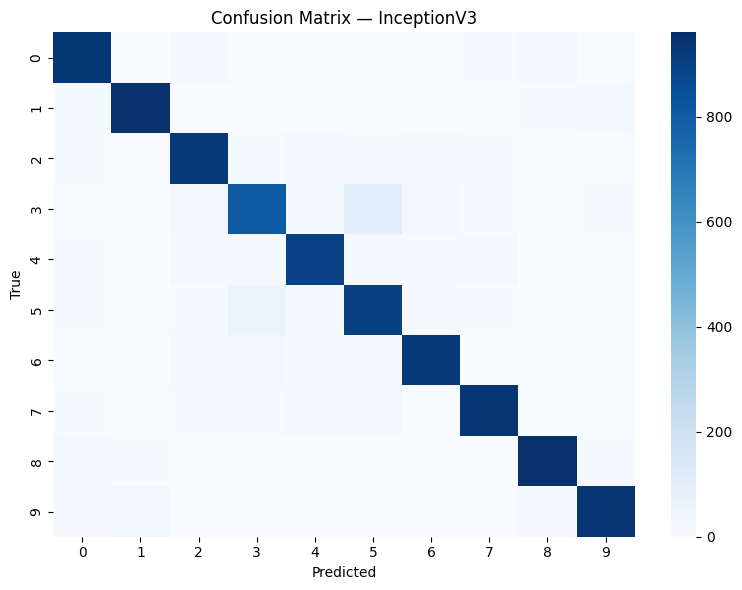

RunSummary(model_name='InceptionV3', image_size=299, epochs_head=5, epochs_finetune=5, train_time_sec=407.826776053, test_loss=0.26385149359703064, test_accuracy=0.9186000227928162, params_million=21.823274, saved_model_mb=181.03276920318604)

In [8]:
inception_summary = train_and_evaluate(
    model_name='InceptionV3',
    build_base_fn=lambda input_size: build_inceptionv3(input_size),
    image_size=299,
    epochs_head=5,
    epochs_finetune=5,
    batch_size=64,
    lr_head=1e-3,
    lr_finetune=1e-5,
    unfreeze_last_n=80,
)
inception_summary

In [9]:
# ===== Comparison table (accuracy, loss, time, model size) =====
summaries = [resnet_summary, inception_summary]

import pandas as pd
df = pd.DataFrame([asdict(s) for s in summaries])
df = df[[
    'model_name', 'image_size', 'epochs_head', 'epochs_finetune',
    'test_accuracy', 'test_loss', 'train_time_sec', 'params_million', 'saved_model_mb'
]]
df

,model_name,image_size,epochs_head,epochs_finetune,test_accuracy,test_loss,train_time_sec,params_million,saved_model_mb
0,ResNet50,224,5,5,0.9475,0.186241,368.940994,23.608202,228.486469
1,InceptionV3,299,5,5,0.9186,0.263851,407.826776,21.823274,181.032769


In [10]:
# Save summary table
summary_csv = DIRS['results'] / 'summary_table.csv'
df.to_csv(summary_csv, index=False)
print('Saved:', summary_csv.resolve())

metrics_json = DIRS['results'] / 'metrics.json'
with metrics_json.open('w') as f:
    json.dump({'runs': [asdict(s) for s in summaries]}, f, indent=2)
print('Saved:', metrics_json.resolve())

Saved: /content/drive/MyDrive/Abdul_Basit_Assignment_03/results/summary_table.csv
Saved: /content/drive/MyDrive/Abdul_Basit_Assignment_03/results/metrics.json


## Observations (write-up starter)
Use the table and plots to justify why one model performed better.

Ideas you can discuss:
- **Input size difference**: InceptionV3 sees more pixels (299×299) than ResNet50 (224×224), which can help but costs more compute.
- **Architecture bias**: Residual connections in ResNet improve gradient flow and often help optimization.
- **Overfitting vs generalization**: Compare train vs val curves.
- **Fine-tuning depth**: Unfreezing more layers can improve accuracy but may overfit if LR is too high.
- **Training time**: Larger inputs and heavier compute raise epoch time.

Below we auto-generate a short report outline you can expand to 3–5 pages.

In [11]:
report_path = DIRS['report'] / 'report.md'

split_train = int((1 - val_fraction) * 100)
split_val = int(val_fraction * 100)

report_lines = [
    '# Assignment 3 Report — ResNet50 vs InceptionV3 (Transfer Learning)',
    '',
    '## 1. Objective',
    'Implement and compare **ResNet50** and **InceptionV3 (GoogLeNet family)** using transfer learning on a standard image dataset.',
    '',
    '## 2. Dataset',
    '- Dataset: **CIFAR-10** (10 classes, 50k train + 10k test)',
    f'- Split: train/val = {split_train}%/{split_val}%',
    '- Preprocessing: resize + model-specific `preprocess_input`',
    '- Augmentation: random flip, brightness, contrast',
    '',
    '## 3. Method',
    '### 3.1 Transfer learning setup',
    '- Start with ImageNet-pretrained backbone (`include_top=False`, global average pooling)',
    '- Replace final layer with a new Dense layer of size 10 with softmax',
    '- Stage 1: freeze backbone, train classifier head',
    '- Stage 2: fine-tune the last backbone layers (BatchNorm kept frozen) with smaller LR',
    '',
    '### 3.2 Training configuration',
    '- Optimizer: Adam',
    '- Loss: categorical cross-entropy',
    '- Metrics: accuracy',
    f'- Epochs per model: head={resnet_summary.epochs_head} + finetune={resnet_summary.epochs_finetune} (ResNet50), head={inception_summary.epochs_head} + finetune={inception_summary.epochs_finetune} (InceptionV3)',
    '',
    '## 4. Results',
    'Summary table saved at: `results/summary_table.csv`',
    '',
    '### 4.1 Curves',
    '- ResNet50: `figures/resnet50_accuracy_loss.png`',
    '- InceptionV3: `figures/inceptionv3_accuracy_loss.png`',
    '',
    '### 4.2 Confusion matrices',
    '- ResNet50: `figures/confusion_matrix_resnet50.png`',
    '- InceptionV3: `figures/confusion_matrix_inceptionv3.png`',
    '',
    '## 5. Discussion / Observations',
    '(Write ~1–2 pages)',
    '',
    'Example points to cover:',
    '1. Which model had higher test accuracy and why?',
    '2. Compare training time and relate it to input resolution and architecture cost.',
    '3. Look at confusion matrices: which classes were commonly confused?',
    '4. Was there overfitting? Use train vs val curves.',
    '5. Explain how residual connections (ResNet) or multi-branch feature extraction (Inception) can affect results.',
    '',
    '## 6. Conclusion',
    '(Short paragraph summarizing best model and trade-offs.)',
]

report_md = '\n'.join(report_lines) + '\n'
report_path.write_text(report_md)
print('Saved:', report_path.resolve())

Saved: /content/drive/MyDrive/Abdul_Basit_Assignment_03/report/report.md
